# Gut Bacteria Project: Prediction & Attention Analysis

This Jupyter Notebook demonstrates how to run the pipeline to predict drug-bacteria interactions and visualize the attention weights of the Multi-Modal Model.

## 1. Check Input Files
Ensure `sample1.txt` is present and the corresponding `.fasta` file is inside the `input/` directory.

In [1]:
import os

input_txt = 'sample1.txt'
print("--- Contents of sample1.txt ---")
with open(input_txt, 'r') as f:
    print(f.read())

--- Contents of sample1.txt ---
drug: Diltiazem
drug smiles: COc1ccc(C2Sc3ccccc3N(CC[NH+](C)C)C(=O)C2OC(C)=O)cc1
bacterial strain name: Bacteroides thetaiotaomicron VPI-5482

target protein: WP_008760980.1


## 2. Run the Prediction Pipeline
We will run `prediction.py` and specify `--target_protein WP_004841162.1` to extract cross-attention information.

*(Note: The first time you run this, KofamScan and ESM-C downloading may take a few minutes. Subsequent runs will use cached results.)*

In [ ]:
!python prediction.py --input_txt sample1.txt --cpu_cores 12 --target_protein WP_008760980.1

## 3. View Attention Visualization
Once the prediction finishes successfully, it outputs attention heatmap images in the `attention_results/` folder. We can load and display them here.

Found 2 attention maps!
Displaying: attention analysis/heatmap for Diltiazem with top 5 protein and target protein.png


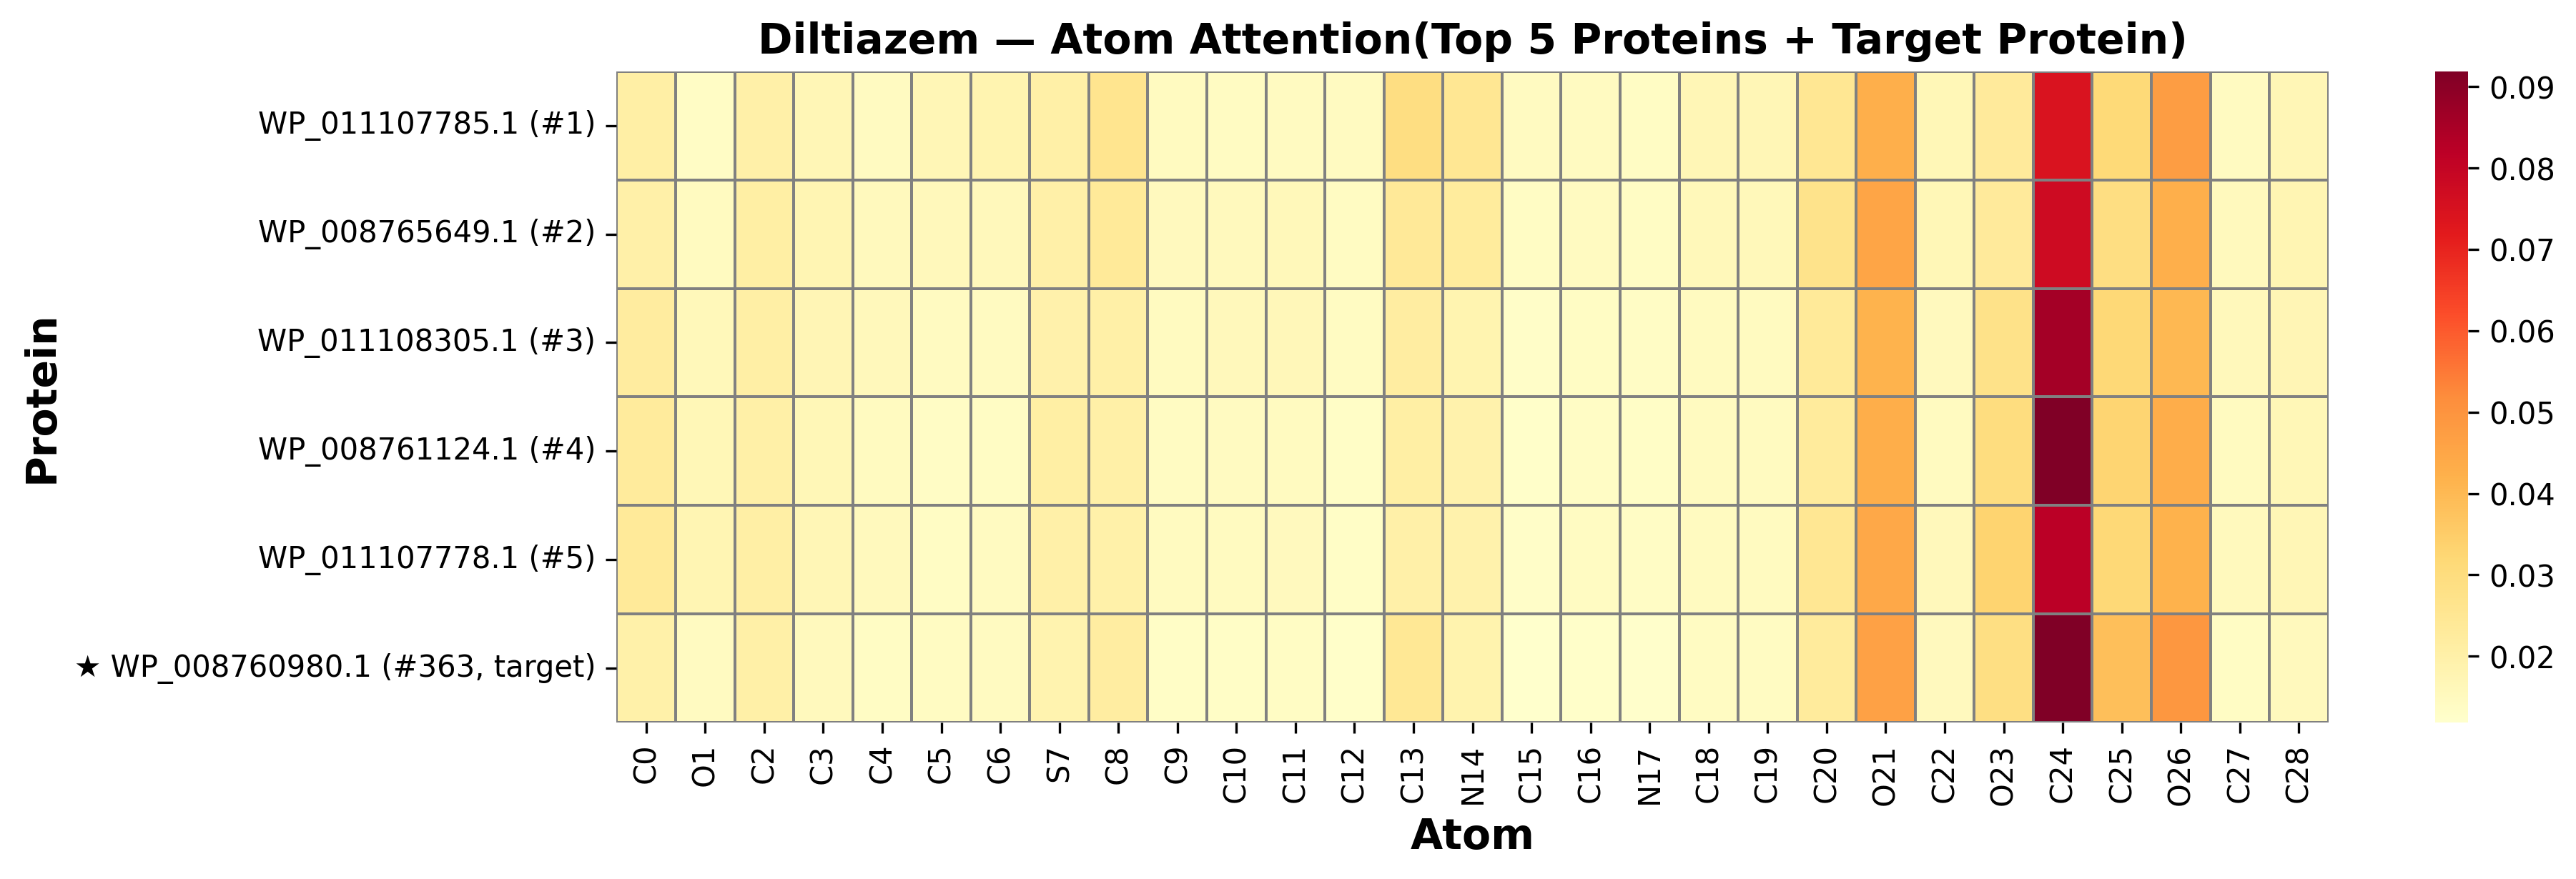

Displaying: attention analysis/Attention Analysis for Diltiazem.svg


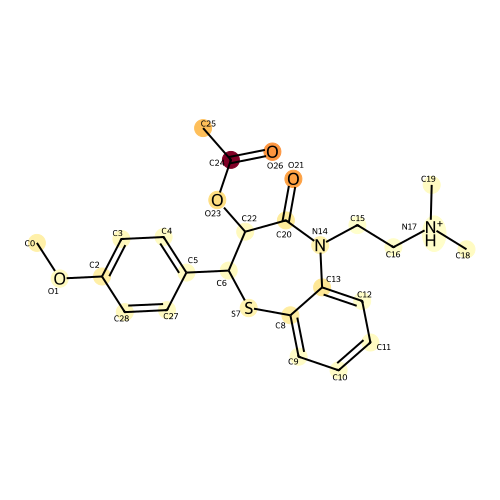

In [5]:
from IPython.display import Image, display, SVG
import glob

attn_images = glob.glob('attention analysis/*.png') + glob.glob('attention analysis/*.svg')

if attn_images:
    print(f"Found {len(attn_images)} attention maps!")
    for img in attn_images:
        print(f"Displaying: {img}")
        if img.lower().endswith('.svg'):
            display(SVG(filename=img))
        else:
            display(Image(filename=img))
else:
    print("Attention visualization images not found. Ensure the pipeline completed successfully.")